In [32]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

In [34]:
from catrace.trial_similarity import compute_population_multitrial_similarity_over_time, plot_matrix_per_condition, SimToTemplateParams, compute_population_multitrial_similarity_over_time_to_template, plot_slicing_per_condition

In [35]:
# Read the results from peresistent index analysis
from catrace.dataset import load_dataset_config
dsconfig = load_dataset_config('../dataset_configs/juvenile_dataset_t7.json')
import os
import pandas as pd
result_dir = os.path.join(dsconfig.results_dir, 'offset_responsive_cluster')
# Read the cluster labels for each odor
labels_df = pd.read_pickle(os.path.join(result_dir, 'matched_cluster_labels.pkl'))    

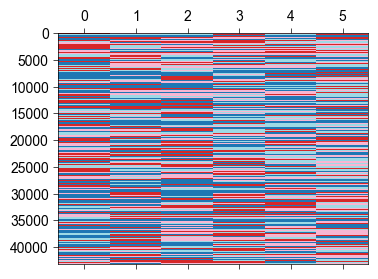

In [36]:
# Plot heatmap of labels_df
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4, 3))
ax.matshow(labels_df.values, aspect='auto', cmap='tab20')


In [37]:
from catrace.trial_similarity import compute_population_multitrial_similarity_over_time, plot_matrix_per_condition, SimToTemplateParams, compute_population_multitrial_similarity_over_time_to_template, plot_slicing_per_condition

import os
import numpy as np
import copy
dataset_name = 'juvenile'
from catrace.for_paper import save_figure_for_paper
paper_fig_dir = '../../figures_for_paper/offset_response/'
os.makedirs(paper_fig_dir, exist_ok=True)
def compute_corr_over_time_slicing(dsconfig, region, similarity_method, odor, select_neurons_by_indices_params=None):
    template_time_ranges = np.array([(2, 7)])
    frame_rate = 7.5
    template_frame_ranges = template_time_ranges * frame_rate+ 2.3*frame_rate
    template_frame_ranges = template_frame_ranges.astype(int)
    template_frame_ranges
    template_frame_range = template_frame_ranges[0]
    #template_frame_range = (38, 63)

    sim_params = SimToTemplateParams(template_frame_range=template_frame_range,
                                    similarity_method=similarity_method,
                                    bin_size=None)

    odor_trials = [(odor, 0), (odor, 1), (odor, 2)]
    simtempdf = compute_population_multitrial_similarity_over_time_to_template(dsconfig, odor_trials, dsconfig.exp_list, sim_params, select_neurons_by_indices_params=select_neurons_by_indices_params)
    return simtempdf



In [38]:

from catrace.dataset import load_dataset_config
dsconfig = load_dataset_config('../dataset_configs/juvenile_dataset_t7.json')
naive_exp_list = [(exp_name, condition) for exp_name, condition in dsconfig.exp_list if condition == 'naive']
naive_dsconfig = copy.deepcopy(dsconfig)
naive_dsconfig.exp_list = naive_exp_list
similarity_method='pattern_correlation'

# Loop over odors

from catrace.trial_similarity import SelectNeuronsByIndicesParams

# Compute similarity
odors = dsconfig.odors_stimuli
#odors = ['Phe']

simdf_merged_dict = {}
for odor in odors:
    idx = labels_df[labels_df[odor] != 2].index
    select_neurons_by_indices_params = SelectNeuronsByIndicesParams(neuron_indices=idx)
    simdf_removed = compute_corr_over_time_slicing(naive_dsconfig, 'Dp', similarity_method, odor, select_neurons_by_indices_params=select_neurons_by_indices_params)
    # Change conditon from naive to naive-remove-offset-responsive. Condition is one of the levels of the multiindex of simdf_removed.index
    # First reset the index to have condition as a column
    simdf_removed = simdf_removed.reset_index(level='condition')
    simdf_removed = simdf_removed.droplevel(-1)
    simdf_removed['condition'] = 'naive-remove-offset-responsive'
    simdf_removed = simdf_removed.set_index('condition', append=True)
    simdf = compute_corr_over_time_slicing(naive_dsconfig, 'Dp', similarity_method, odor, select_neurons_by_indices_params=None)
    # Drop the last level in simdf.index
    simdf = simdf.droplevel(-1)

    # Merge simdf and simdf_removed
    simdf_merged = pd.concat([simdf, simdf_removed])
    simdf_merged_dict[odor] = simdf_merged


2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022

In [39]:
def plot_corr_over_time_slicing(simtempdf, similarity_method, frame_rate, ax=None, label=None, ylim=None, pallete=None):

    # Create a figure with 4 subplots in a row
    # Plot each simtempdf for each odor with shared y axis

    figsize = (1.2, 1.05)
    label_fontsize = 7
    tick_fontsize = 6
    xtick_interval = 2
    linewidth = 0.5
    std_alpha = 0.15
    err_type = 'std'
    fig, ax = plt.subplots(figsize=figsize)

    if pallete is not None:
        colors = pallete
    else:
        colors = {'naive': 'darkblue', 
                'arg-phe': 'salmon',
                'phe-arg': 'm',
                'phe-trp': 'tab:green',
                'naive-remove-offset-responsive': 'green'}

    # Only one odor is plotted

    # Plot the simtempdf on the current axis
    cut_time = 2.3
    frame_range = ((np.array([0, 12])+cut_time)*frame_rate).astype(int)
    simdf_slicing_dict = plot_slicing_per_condition(simtempdf, metric=similarity_method, colors=colors, 
                            frame_range=frame_range, frame_rate=dsconfig.frame_rate, ax=ax,
                            linewidth=linewidth,
                            std_alpha=std_alpha,
                            err_type=err_type)
    ax.set_title(odor, fontsize=label_fontsize)
    # Set x tick interval to 1 with MultipleLocator
    ax.xaxis.set_major_locator(plt.MultipleLocator(xtick_interval))
    # Set x and y tick label font size
    ax.set_xlabel('Time (s)', fontsize=label_fontsize)
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    # Despine
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', length=1.5)


    # Add a super title for the entire figure
    #fig.suptitle('Similarity Over Time to Template for Each Odor')

    # Set the y label for the first axis
    if similarity_method == 'pattern_correlation':
        metric_label = 'Corr. coeff. to template'
    elif similarity_method == 'cosine':
        metric_label = 'Cosine distance to template'
    else:
        metric_label = similarity_method

    ax.set_ylabel(metric_label, fontsize=tick_fontsize)
    fig.tight_layout()

    ax.legend().remove()
    if ylim is not None:
        ax.set_ylim(ylim)
                
    return fig, ax, simdf_slicing_dict


C:\Users\hubob\AppData\Local\Temp\ipykernel_3340\4060420232.py:58: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
C:\Users\hubob\AppData\Local\Temp\ipykernel_3340\4060420232.py:58: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
C:\Users\hubob\AppData\Local\Temp\ipykernel_3340\4060420232.py:58: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
C:\Users\hubob\AppData\Local\Temp\ipykernel_3340\4060420232.py:58: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
C:\Users\hubob\AppData\Local\Temp\ipykernel_3340\4060420232.py:58: UserWarning: Tight layout not applied. The left and right

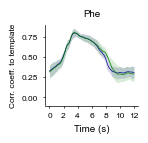

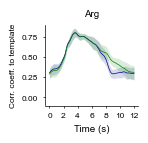

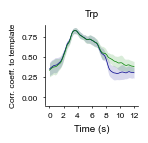

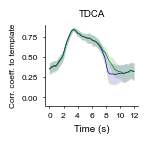

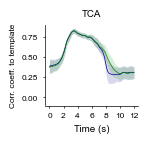

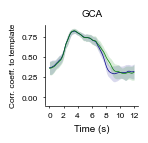

In [40]:

from catrace.for_paper import save_figure_for_paper
paper_fig_root_dir = '../../figures_for_paper'
paper_fig_dir = os.path.join(paper_fig_root_dir, 'juvenile/offset_response/correlation_over_time/')
os.makedirs(paper_fig_dir, exist_ok=True)

# Plot similarity
simdf_slicing_dict_dict = {}
for odor in odors:
    simdf_merged = simdf_merged_dict[odor]
    fig, ax, simdf_slicing_dict = plot_corr_over_time_slicing(simdf_merged, similarity_method, naive_dsconfig.frame_rate, ax=None, label=odor, ylim = (-0.1, 0.9))
    simdf_slicing_dict_dict[odor] = simdf_slicing_dict
    fig_name = f'{dataset_name}_similarity_over_time_to_template_{similarity_method}_{odor}'
    save_figure_for_paper(fig, fig_name, paper_fig_dir)

In [72]:
# First concatenate over ['naive', 'naive-remove-offset-responsive']
simdf_slicing_concat_dict = {}

for odor in odors:
    simdf_slicing_dict = simdf_slicing_dict_dict[odor]
    # Concatenate over conditions
    simdf_slicing_concat = pd.concat(simdf_slicing_dict.values(), axis=1)
    # rename index level time to frame
    simdf_slicing_concat.index = simdf_slicing_concat.index.set_names('frame')
    # Append time_vec as new level in index
    time_vec = simdf_slicing_concat.index.get_level_values('frame') / dsconfig.frame_rate - 2.3
    simdf_slicing_concat.index = pd.MultiIndex.from_arrays([time_vec] + [simdf_slicing_concat.index.get_level_values(i) for i in range(simdf_slicing_concat.index.nlevels)], names=['time'] + list(simdf_slicing_concat.index.names))
    simdf_slicing_concat_dict[odor] = simdf_slicing_concat

# Then concatenate over odors
simdf_slicing_concat_all = pd.concat(simdf_slicing_concat_dict.values(), axis=1)

# Save result data to CSV
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'extended_figure04')
os.makedirs(save_dir, exist_ok=True)
simdf_slicing_concat_all.to_csv(os.path.join(save_dir, f'extended_figure04e_pattern_corr_to_template_remove_offset_response.csv'))

In [41]:
# Compute similarity
odors = dsconfig.odors_stimuli
#odors = ['Phe']

selected_cluster = 1
action = 'keep'
legend_label = f'naive-{action}-cluster-{selected_cluster}'
pallete = {'naive': 'darkblue', legend_label: 'tab:cyan'}

simdf_merged_dict = {}
for odor in odors:
    if action == 'keep':
        idx = labels_df[labels_df[odor] == selected_cluster].index
    else:
        idx = labels_df[labels_df[odor] != selected_cluster].index
    select_neurons_by_indices_params = SelectNeuronsByIndicesParams(neuron_indices=idx)
    simdf_selected = compute_corr_over_time_slicing(naive_dsconfig, 'Dp', similarity_method, odor, select_neurons_by_indices_params=select_neurons_by_indices_params)
    # Change conditon from naive to naive-remove-offset-responsive. Condition is one of the levels of the multiindex of simdf_removed.index
    # First reset the index to have condition as a column
    simdf_selected = simdf_selected.reset_index(level='condition')
    simdf_selected = simdf_selected.droplevel(-1)
    simdf_selected['condition'] = legend_label
    simdf_selected = simdf_selected.set_index('condition', append=True)
    simdf = compute_corr_over_time_slicing(naive_dsconfig, 'Dp', similarity_method, odor, select_neurons_by_indices_params=None)
    # Drop the last level in simdf.index
    simdf = simdf.droplevel(-1)

    # Merge simdf and simdf_selected
    simdf_merged = pd.concat([simdf, simdf_selected])
    simdf_merged_dict[odor] = simdf_merged

2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022

C:\Users\hubob\AppData\Local\Temp\ipykernel_3340\4060420232.py:58: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
C:\Users\hubob\AppData\Local\Temp\ipykernel_3340\4060420232.py:58: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
C:\Users\hubob\AppData\Local\Temp\ipykernel_3340\4060420232.py:58: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
C:\Users\hubob\AppData\Local\Temp\ipykernel_3340\4060420232.py:58: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
C:\Users\hubob\AppData\Local\Temp\ipykernel_3340\4060420232.py:58: UserWarning: Tight layout not applied. The left and right

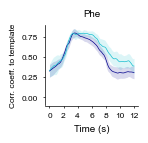

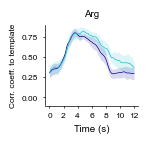

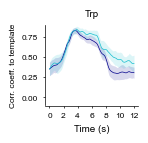

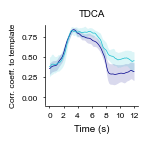

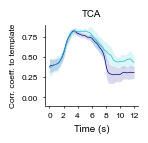

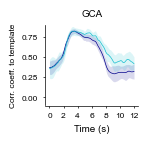

In [73]:
# Plot similarity
simdf_slicing_dict_dict = {}
for odor in odors:
    simdf_merged = simdf_merged_dict[odor]
    fig, ax, simdf_slicing_dict = plot_corr_over_time_slicing(simdf_merged, similarity_method, naive_dsconfig.frame_rate, ax=None, label=odor, ylim = (-0.1, 0.9), pallete=pallete)
    simdf_slicing_dict_dict[odor] = simdf_slicing_dict
    fig_name = f'{dataset_name}_similarity_over_time_to_template_{similarity_method}_{action}_cluster{selected_cluster}_{odor}'
    save_figure_for_paper(fig, fig_name, paper_fig_dir)

In [74]:
# First concatenate over condition
simdf_slicing_concat_dict = {}

for odor in odors:
    simdf_slicing_dict = simdf_slicing_dict_dict[odor]
    # Concatenate over conditions
    simdf_slicing_concat = pd.concat(simdf_slicing_dict.values(), axis=1)
    # rename index level time to frame
    simdf_slicing_concat.index = simdf_slicing_concat.index.set_names('frame')
    # Append time_vec as new level in index
    time_vec = simdf_slicing_concat.index.get_level_values('frame') / dsconfig.frame_rate - 2.3
    simdf_slicing_concat.index = pd.MultiIndex.from_arrays([time_vec] + [simdf_slicing_concat.index.get_level_values(i) for i in range(simdf_slicing_concat.index.nlevels)], names=['time'] + list(simdf_slicing_concat.index.names))
    simdf_slicing_concat_dict[odor] = simdf_slicing_concat

# Then concatenate over odors
simdf_slicing_concat_all = pd.concat(simdf_slicing_concat_dict.values(), axis=1)

# Save result data to CSV
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'extended_figure04')
os.makedirs(save_dir, exist_ok=True)
simdf_slicing_concat_all.to_csv(os.path.join(save_dir, f'extended_figure04e_pattern_corr_to_template_keep_persistent_neurons.csv'))
simdf_slicing_concat_all

odor                                 Phe                          \
trial                                  0                           
fish_id          2021-07-15-DpOBEM-N2_Dp 2021-07-16-DpOBEM-N3_Dp   
condition                          naive                   naive   
time       frame                                                   
-0.033333  17                   0.335645                0.230771   
 0.100000  18                   0.351049                0.239387   
 0.233333  19                   0.384454                0.258182   
 0.366667  20                   0.403140                0.276896   
 0.500000  21                   0.393924                0.291497   
...                                  ...                     ...   
 11.433333 103                  0.298303                0.293384   
 11.566667 104                  0.294671                0.286815   
 11.700000 105                  0.277176                0.280500   
 11.833333 106                  0.271668                0.274718   
 11.966667 107                  0.281570                0.270797   

odor                                                              \
trial                                                              
fish_id          2021-12-10-DpOBEM-N4_Dp 2021-12-31-DpOBEM-N7_Dp   
condition                          naive                   naive   
time       frame                                                   
-0.033333  17                   0.390882                0.308244   
 0.100000  18                   0.408883                0.308817   
 0.233333  19                   0.407725                0.305163   
 0.366667  20                   0.410211                0.305715   
 0.500000  21                   0.413805                0.320956   
...                                  ...                     ...   
 11.433333 103                  0.341037                0.231029   
 11.566667 104                  0.370786                0.233508   
 11.700000 105                  0.392176                0.246221   
 11.833333 106                  0.398019                0.258367   
 11.966667 107                  0.391362                0.269652   

odor                                                                \
trial                                                                
fish_id          2022-02-13-DpOBEM-N10_Dp 2022-02-20-DpOBEM-N11_Dp   
condition                           naive                    naive   
time       frame                                                     
-0.033333  17                    0.316236                 0.449914   
 0.100000  18                    0.309934                 0.473805   
 0.233333  19                    0.307920                 0.483666   
 0.366667  20                    0.322620                 0.489758   
 0.500000  21                    0.334862                 0.499869   
...                                   ...                      ...   
 11.433333 103                   0.224107                 0.392456   
 11.566667 104                   0.221808                 0.380728   
 11.700000 105                   0.225002                 0.365704   
 11.833333 106                   0.232271                 0.355235   
 11.966667 107                   0.236933                 0.349034   

odor                                                              \
trial                                  1                           
fish_id          2021-07-15-DpOBEM-N2_Dp 2021-07-16-DpOBEM-N3_Dp   
condition                          naive                   naive   
time       frame                                                   
-0.033333  17                   0.297408                0.232571   
 0.100000  18                   0.306935                0.244676   
 0.233333  19                   0.305633                0.237940   
 0.366667  20                   0.300581                0.246443   
 0.500000  21                   0.263048                0.261633   
...                  